<a href="https://colab.research.google.com/github/Sinrez/PythonProjects/blob/main/pid1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Демонстрация пропорционального управления

1. Влияние разных значений Kp на реакцию системы
График сохранен как 'proportional_demo.png'


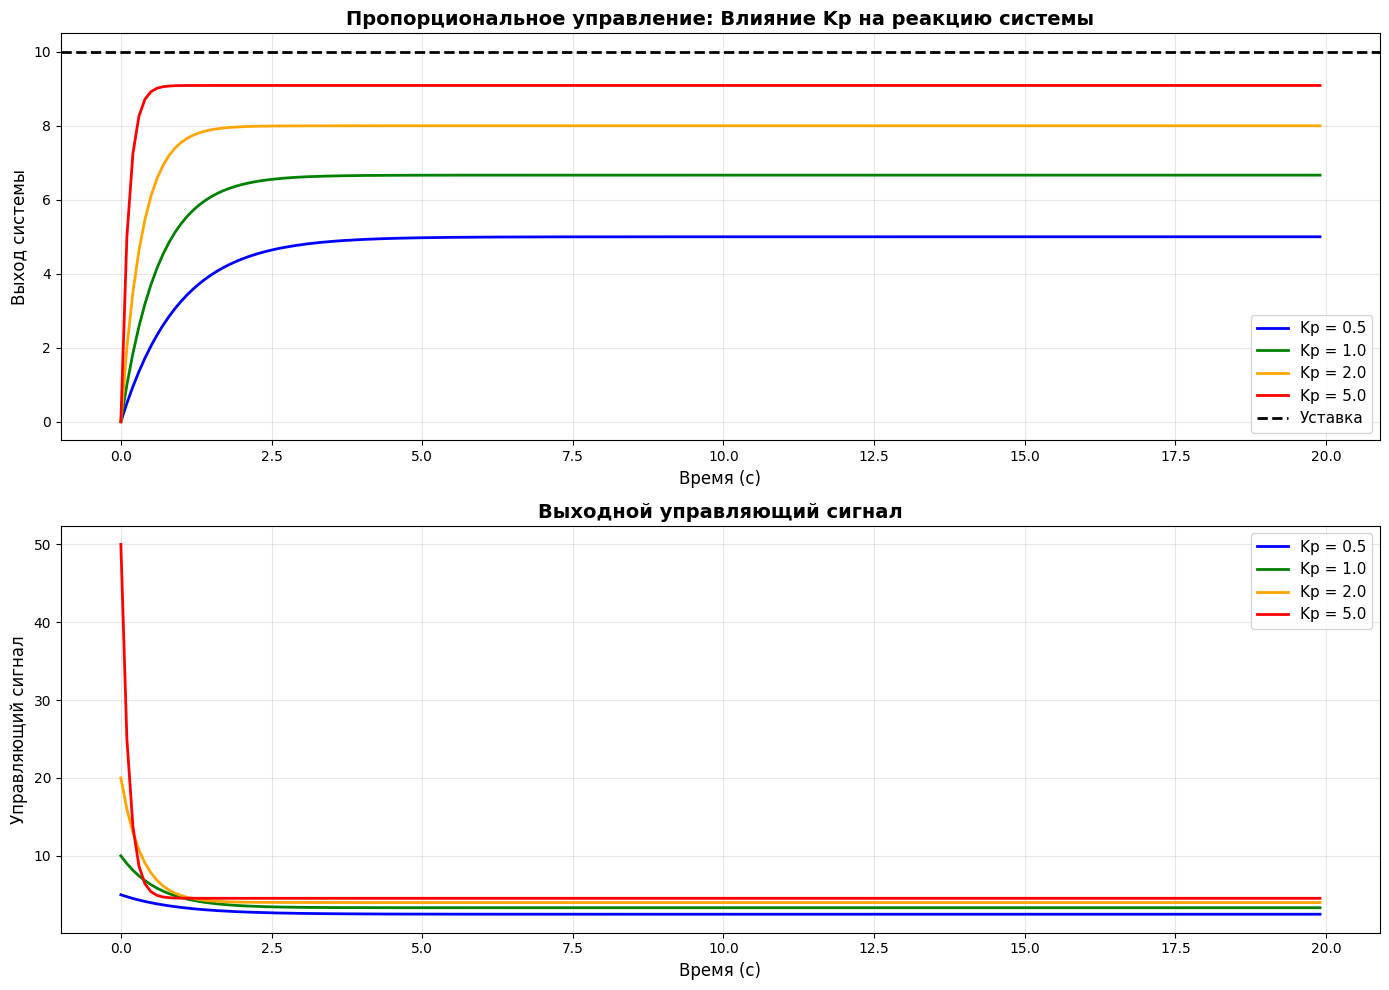


2. Демонстрация установившейся ошибки
График сохранен как 'steady_state_error.png'


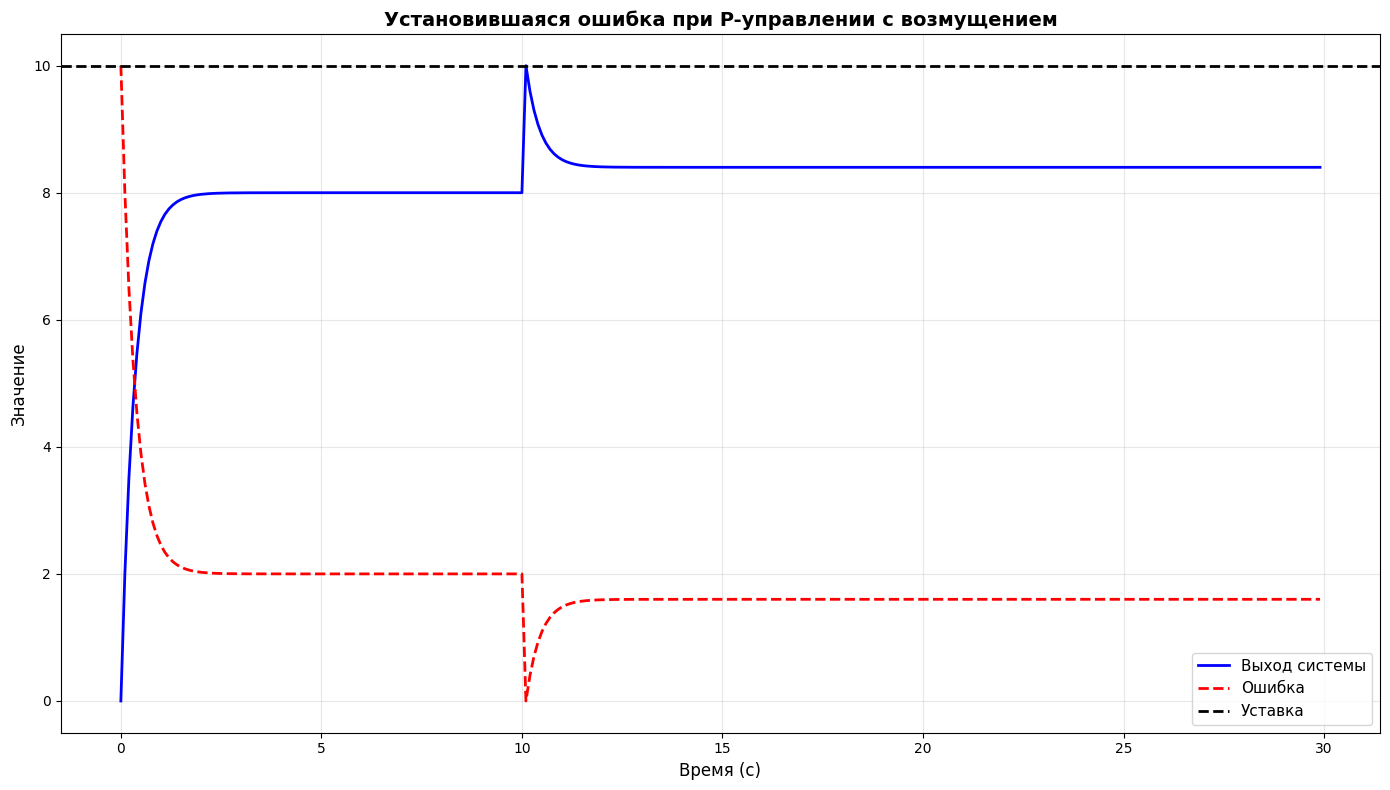

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Простой класс для P-регулятора
class PController:
    def __init__(self, kp, setpoint):
        self.kp = kp
        self.setpoint = setpoint
        self.history = []

    def update(self, current_value):
        error = self.setpoint - current_value
        output = self.kp * error
        self.history.append({'error': error, 'output': output})
        return output

# Простая система первого порядка
class SimpleSystem:
    def __init__(self, initial_value=0.0):
        self.value = initial_value
        self.history = []

    def update(self, input_signal, dt=0.1):
        # Простая модель: dy/dt = u - y/2
        derivative = input_signal - self.value / 2.0
        self.value += derivative * dt
        self.history.append(self.value)
        return self.value

# Симуляция с разными значениями Kp
def simulate_proportional_control():
    dt = 0.1
    simulation_time = 20.0
    setpoint = 10.0
    initial_value = 0.0

    # Тестируем разные значения Kp
    kp_values = [0.5, 1.0, 2.0, 5.0]
    colors = ['blue', 'green', 'orange', 'red']

    plt.figure(figsize=(14, 10))

    # График 1: Реакция системы
    plt.subplot(2, 1, 1)

    for kp, color in zip(kp_values, colors):
        system = SimpleSystem(initial_value)
        controller = PController(kp, setpoint)

        time_points = []
        system_values = []

        for t in np.arange(0, simulation_time, dt):
            current_value = system.value
            control_signal = controller.update(current_value)
            system.update(control_signal, dt)

            time_points.append(t)
            system_values.append(current_value)

        plt.plot(time_points, system_values,
                 label=f'Kp = {kp}', color=color, linewidth=2)

    plt.axhline(y=setpoint, color='black', linestyle='--', label='Уставка', linewidth=2)
    plt.xlabel('Время (с)', fontsize=12)
    plt.ylabel('Выход системы', fontsize=12)
    plt.title('Пропорциональное управление: Влияние Kp на реакцию системы', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    # График 2: Управляющий сигнал
    plt.subplot(2, 1, 2)

    for kp, color in zip(kp_values, colors):
        system = SimpleSystem(initial_value)
        controller = PController(kp, setpoint)

        time_points = []
        control_signals = []

        for t in np.arange(0, simulation_time, dt):
            current_value = system.value
            control_signal = controller.update(current_value)
            system.update(control_signal, dt)

            time_points.append(t)
            control_signals.append(control_signal)

        plt.plot(time_points, control_signals,
                 label=f'Kp = {kp}', color=color, linewidth=2)

    plt.xlabel('Время (с)', fontsize=12)
    plt.ylabel('Управляющий сигнал', fontsize=12)
    plt.title('Выходной управляющий сигнал', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('proportional_demo.png', dpi=300, bbox_inches='tight')
    print("График сохранен как 'proportional_demo.png'")
    plt.show()

# Демонстрация установившейся ошибки
def demonstrate_steady_state_error():
    dt = 0.1
    simulation_time = 30.0
    setpoint = 10.0

    plt.figure(figsize=(14, 8))

    system = SimpleSystem(0.0)
    controller = PController(kp=2.0, setpoint=setpoint)

    time_points = []
    system_values = []
    errors = []

    for t in np.arange(0, simulation_time, dt):
        current_value = system.value

        # Применяем возмущение после 10 секунд
        if t > 10.0:
            current_value += 2.0  # Постоянное возмущение

        control_signal = controller.update(current_value)
        system.update(control_signal, dt)

        time_points.append(t)
        system_values.append(current_value)
        errors.append(setpoint - current_value)

    plt.plot(time_points, system_values, label='Выход системы',
             linewidth=2, color='blue')
    plt.plot(time_points, errors, label='Ошибка',
             linewidth=2, color='red', linestyle='--')
    plt.axhline(y=setpoint, color='black', linestyle='--',
                label='Уставка', linewidth=2)
    plt.xlabel('Время (с)', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.title('Установившаяся ошибка при P-управлении с возмущением',
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('steady_state_error.png', dpi=300, bbox_inches='tight')
    print("График сохранен как 'steady_state_error.png'")
    plt.show()

# Запуск демонстраций
if __name__ == '__main__':
    print("=" * 60)
    print("Демонстрация пропорционального управления")
    print("=" * 60)

    print("\n1. Влияние разных значений Kp на реакцию системы")
    simulate_proportional_control()

    print("\n2. Демонстрация установившейся ошибки")
    demonstrate_steady_state_error()